### dataset

link: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Columns:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality (Target)

### Step 1: Data Loading & Understanding

1.1 Load dataset using pandas. Display first 5 rows

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


1.2 Print dataset shape

In [3]:
df.shape

(1599, 12)

1.3 Display column names and data types

In [4]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

1.4 Check missing values

In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

1.5 Analyze distribution of quality

In [6]:
import matplotlib.pyplot as plt

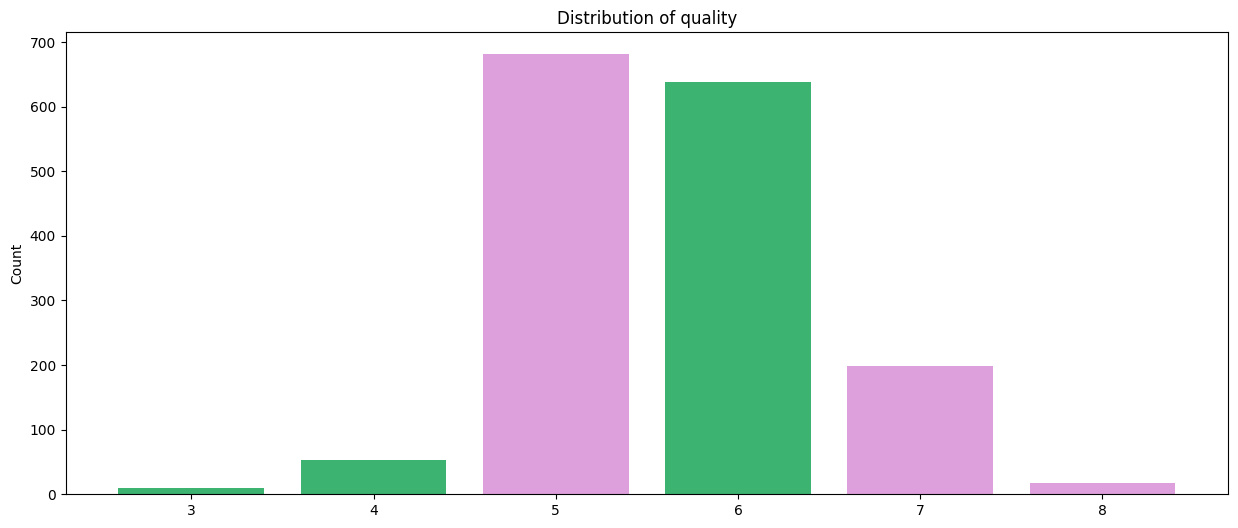

In [7]:
x = df["quality"].value_counts()
y = df["quality"].unique()

colors = ["plum", "mediumseagreen"]

plt.figure(figsize=(15,6))
plt.bar(y, x, color=colors)
plt.title("Distribution of quality")
plt.ylabel("Count")
plt.show()

1.6 Convert quality into multiclass label (e.g., keep 0–10 or group into 3 classes)

In [8]:
def quality_group(q):
    if q <= 4:
        return 0 #low
    elif q <= 6:
        return 1 #medium
    else:
        return 2 #high

df["quality_class"] = df["quality"].apply(quality_group)

In [9]:
df["quality_class"].unique()

array([1, 2, 0])

### Step 2: Data Preprocessing

2.1 Remove duplicates

In [10]:
duplicated = df[df.duplicated()]
duplicated

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_class
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5,1
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5,1
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5,1
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,1
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,1
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,1
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5,1


In [11]:
df = df.drop_duplicates()
duplicated = df[df.duplicated()]
duplicated

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_class


2.3 Separate X (features) and y (target)

In [12]:
y = df["quality_class"]
X = df.drop(columns=["quality", "quality_class"])

2.4 Normalize features using StandardScaler

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2.5 Encode target properly (class indices for CrossEntropyLoss)

In [15]:
print(y.unique())

[1 2 0]


2.6 Train-test split (80/20)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

2.7 Convert to tensors

In [18]:
import torch
import numpy as np

In [19]:
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor  = torch.tensor(np.array(X_test), dtype=torch.float32)

y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
y_test_tensor  = torch.tensor(np.array(y_test), dtype=torch.long)

### Step 3: Neural Network Architecture

Model:
- Input layer = number of features
- Hidden layer 1 (64 neurons, ReLU)
- Hidden layer 2 (32 neurons, ReLU)
- Output layer = number of classes
- No Softmax (use inside loss)
- Loss: CrossEntropyLoss
- Optimizer: Adam
- Epochs: 50–100

In [20]:
import torch.nn as nn
import torch.optim as optim

In [22]:
input_size = X_train_tensor.shape[1]
num_classes = 3

class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)


model = NeuralNet(input_size, num_classes)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [24]:
epochs = 100

for epoch in range(epochs):
    model.train()
    
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.9061
Epoch [20/100], Loss: 0.7634
Epoch [30/100], Loss: 0.6472
Epoch [40/100], Loss: 0.5726
Epoch [50/100], Loss: 0.5250
Epoch [60/100], Loss: 0.4954
Epoch [70/100], Loss: 0.4754
Epoch [80/100], Loss: 0.4611
Epoch [90/100], Loss: 0.4501
Epoch [100/100], Loss: 0.4408


### Step 4: Evaluation

4.1 Compute:
- Accuracy
- Precision
- Recall
- F1-score

In [33]:
model.eval()

#test
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)

In [26]:
y_true = y_test_tensor.cpu().numpy()
y_pred = predicted.cpu().numpy()

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [28]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8382352941176471
Precision: 0.7860086574952563
Recall: 0.8382352941176471
F1-score: 0.8066681712796734


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
#train
with torch.no_grad():
    outputsTr = model(X_train_tensor)
    _, predictedTr = torch.max(outputsTr, 1)

y_true_tr = y_train_tensor.cpu().numpy()
y_pred_tr = predictedTr.cpu().numpy()

accuracyTr = accuracy_score(y_true_tr, y_pred_tr)
precisionTr = precision_score(y_true_tr, y_pred_tr, average='weighted')
recallTr = recall_score(y_true_tr, y_pred_tr, average='weighted')
f1Tr = f1_score(y_true_tr, y_pred_tr, average='weighted')

print("Accuracy:", accuracyTr)
print("Precision:", precisionTr)
print("Recall:", recallTr)
print("F1-score:", f1Tr)

Accuracy: 0.8362465501379944
Precision: 0.7818918530900756
Recall: 0.8362465501379944
F1-score: 0.8001525423975142


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


4.2 Plot confusion matrix

In [29]:
from sklearn.metrics import confusion_matrix

In [30]:
cm = confusion_matrix(y_true, y_pred)

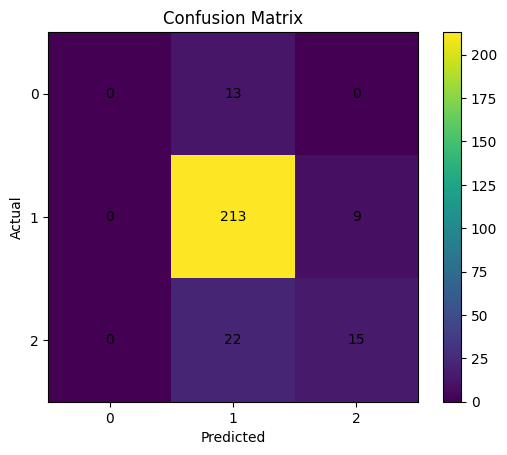

In [31]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(np.arange(3))
plt.yticks(np.arange(3))

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

- Diagonal → correct predictions
- Off-diagonal → misclassifications

4.3 Analyze class imbalance

In [32]:
print(pd.Series(y_train).value_counts())

quality_class
1    890
2    147
0     50
Name: count, dtype: int64
